PROBELM 1: Differentiation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

In [2]:
from pathlib import Path

base_dir = Path("solutions.ipynb").resolve().parent
figures_dir = base_dir / "figures"
figures_dir.mkdir(exist_ok="True")

In [3]:
from matplotlib.pyplot import rcParams

rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "axes.linewidth": 2,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "legend.fontsize": 16,
    "lines.linewidth": 3,
    "lines.markersize": 8
})

In [4]:
# (a) differentiate using single precision forward-, central-, and extrapolated-difference algorithms

# functions we want to differentiate

x_list = [0.1, 10]

def f(x):
    x = np.float32(x)
    return np.cos(x)

def g(x):
    x = np.float32(x)
    return np.exp(x)

def f_prime_analytic(x):
    x = np.float32(x)
    return -np.sin(x)

def g_prime_analytic(x):
    x = np.float32(x)
    return np.exp(x)

# our three difference algorithms

def forward_difference(f, x, h):
    x = np.float32(x)
    h = np.float32(h)
    return (f(x+h) - f(x)) / h

def central_difference(f, x, h):
    x = np.float32(x)
    h = np.float32(h)
    return (f(x+h) - f(x-h)) / (np.float32(2)*h)

def extrapolated_difference(f, x, h, n):
    x = np.float32(x)
    h = np.float32(h)
    F = np.zeros((n,n), dtype=np.float32)

    for i in range(n):
        hi = h/np.float32(2**i)
        F[i,0] = central_difference(f, x, hi)

    for j in range(1,n):
        for i in range(j, n):
            F[i,j] = (np.float32(1)/(np.float32(4**j) - np.float32(1))) * (np.float32(4**j) * F[i, j-1] - F[i-1, j-1])

    return F[n-1, n-1]

# relative error (fractional)

def relative_error(approx, exact):
    approx = np.float32(approx)
    exact = np.float32(exact)
    return np.abs((approx - exact) / exact)

In [5]:
# let's test various n and wider range of h as well

results = []

for x in x_list:

    f_prime_analytical = f_prime_analytic(x)
    g_prime_analytical = g_prime_analytic(x)

    for h in np.logspace(-7, 1, 100, dtype = np.float32):
        f_prime_forward = forward_difference(f, x, h)
        f_prime_central = central_difference(f, x, h)

        error_f_forward = relative_error(f_prime_forward, f_prime_analytical)
        error_f_central = relative_error(f_prime_central, f_prime_analytical)

        g_prime_forward = forward_difference(g, x, h)
        g_prime_central = central_difference(g, x, h)

        error_g_forward = relative_error(g_prime_forward, g_prime_analytical)
        error_g_central = relative_error(g_prime_central, g_prime_analytical)

        for n in [2, 3, 4]:
            f_prime_extrapolated = extrapolated_difference(f, x, h, n)
            g_prime_extrapolated = extrapolated_difference(g, x, h, n)

            error_f_extrapolated = relative_error(f_prime_extrapolated, f_prime_analytical)
            error_g_extrapolated = relative_error(g_prime_extrapolated, g_prime_analytical)

            results.append({
                "x": x,
                "h": h,
                "n": n,
                "f_exact": f_prime_analytical,
                "f_forward": f_prime_forward,
                "f_forward_error": error_f_forward,
                "f_central": f_prime_central,
                "f_central_error": error_f_central,
                "f_extrapolated": f_prime_extrapolated,
                "f_extrapolated_error": error_f_extrapolated,
                "g_exact": g_prime_analytical,
                "g_forward": g_prime_forward,
                "g_forward_error": error_g_forward,
                "g_central": g_prime_central,
                "g_central_error": error_g_central,
                "g_extrapolated": g_prime_extrapolated,
                "g_extrapolated_error": error_g_extrapolated,
            })


results_df = pd.DataFrame(results)

In [6]:
results_df

,x,h,n,f_exact,f_forward,f_forward_error,f_central,f_central_error,f_extrapolated,f_extrapolated_error,g_exact,g_forward,g_forward_error,g_central,g_central_error,g_extrapolated,g_extrapolated_error
0,0.1,1.000000e-07,2,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.192093e+00,0.078650,1.192093e+00,0.078650
1,0.1,1.000000e-07,3,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.192093e+00,0.078650,2.887514e+00,1.612731
2,0.1,1.000000e-07,4,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.192093e+00,0.078650,5.793951e+00,4.242583
3,0.1,1.204504e-07,2,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,9.896965e-01,0.104486,9.896965e-01,0.104486,9.896965e-01,0.104486
4,0.1,1.204504e-07,3,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,9.896965e-01,0.104486,9.896965e-01,0.104486,2.397265e+00,1.169135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,10.0,8.302176e+00,3,0.544021,0.203918,0.625165,0.059055,0.891446,0.376914,0.307170,22026.464844,1.069632e+07,484.612030,5.349484e+06,241.866211,1.032070e+05,3.685591
596,10.0,8.302176e+00,4,0.544021,0.203918,0.625165,0.059055,0.891446,0.540250,0.006932,22026.464844,1.069632e+07,484.612030,5.349484e+06,241.866211,2.122513e+04,0.036380
597,10.0,1.000000e+01,2,0.544021,0.124715,0.770753,-0.029596,1.054402,-0.129248,1.237579,22026.464844,4.851432e+07,2201.546631,2.425826e+07,1100.323364,-7.650238e+06,348.320251
598,10.0,1.000000e+01,3,0.544021,0.124715,0.770753,-0.029596,1.054402,0.230933,0.575507,22026.464844,4.851432e+07,2201.546631,2.425826e+07,1100.323364,4.696022e+05,20.319906


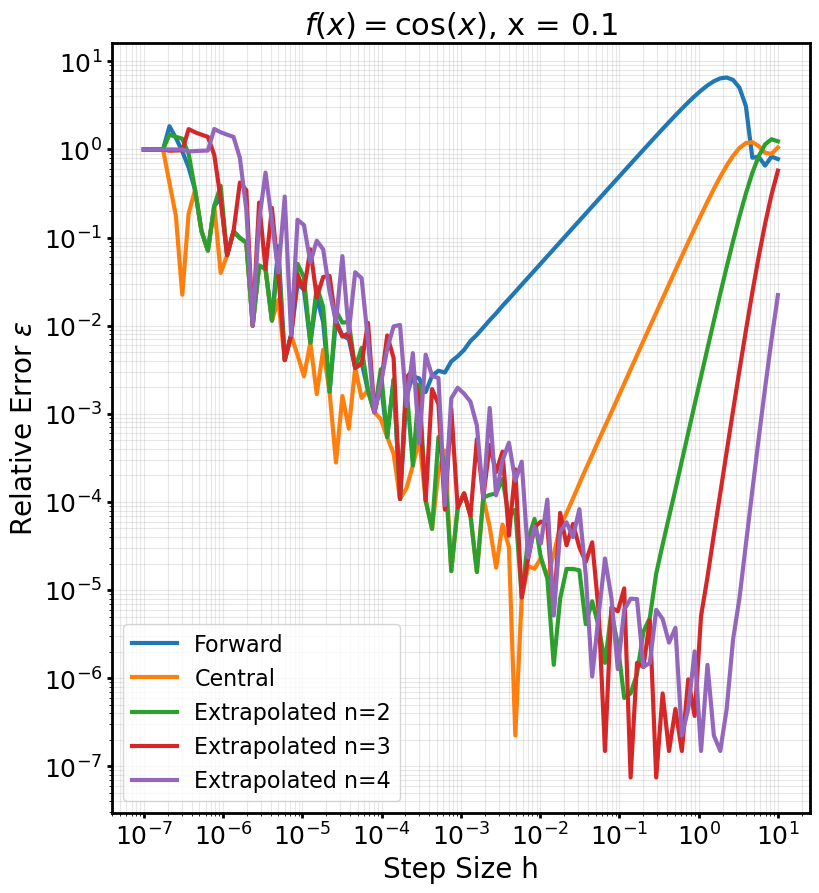


$f(x)=\cos(x)$, x=0.1
forward: h = 1.707e-04, min error = 1.081e-04, digits ~ 3.97
central: h = 4.863e-03, min error = 2.239e-07, digits ~ 6.65
extrapolated n=2: h = 1.150e-01, min error = 5.970e-07, digits ~ 6.22
extrapolated n=3: h = 1.385e-01, min error = 7.463e-08, digits ~ 7.13
extrapolated n=4: h = 1.072e+00, min error = 1.493e-07, digits ~ 6.83


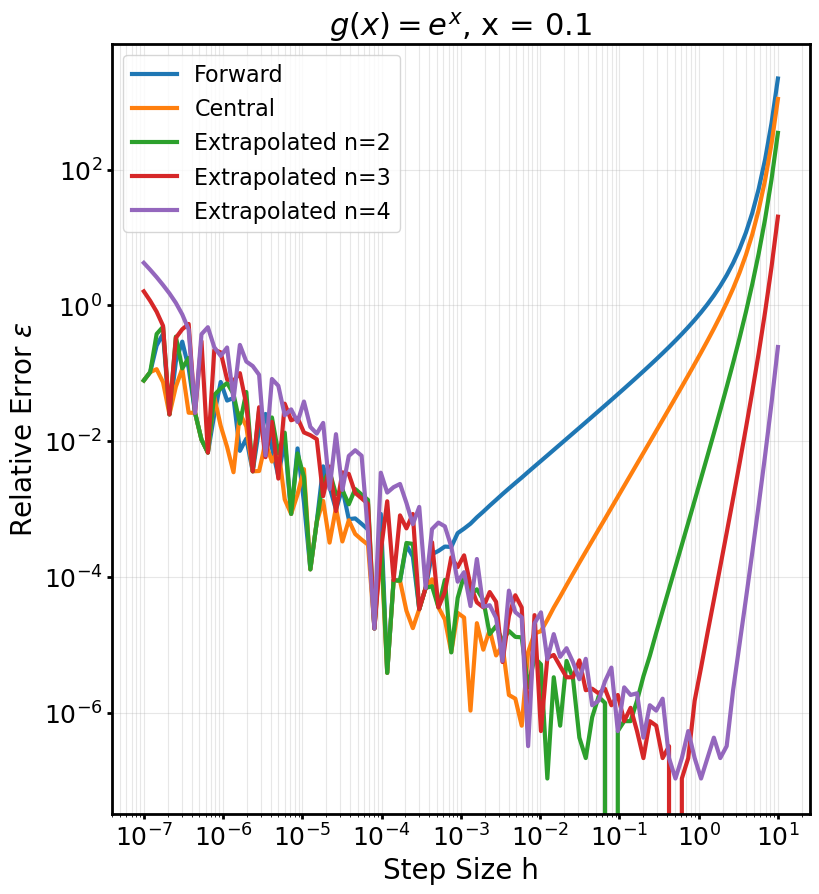


$g(x)=e^x$, x=0.1
forward: h = 1.177e-04, min error = 3.883e-06, digits ~ 5.41
central: h = 5.857e-03, min error = 6.472e-07, digits ~ 6.19
extrapolated n=2: h = 7.925e-02, min error = 0.000e+00, digits ~ inf
extrapolated n=3: h = 5.094e-01, min error = 0.000e+00, digits ~ inf
extrapolated n=4: h = 5.094e-01, min error = 1.079e-07, digits ~ 6.97


/var/folders/ks/tnkhxf057b1010qtn3f6lk1c0000gn/T/ipykernel_77821/2272565043.py:46: RuntimeWarning: divide by zero encountered in log10
  print(f"extrapolated n={n}: h = {h_best:.3e}, min error = {err:.3e}, digits ~ {-np.log10(err):.2f}")
/var/folders/ks/tnkhxf057b1010qtn3f6lk1c0000gn/T/ipykernel_77821/2272565043.py:46: RuntimeWarning: divide by zero encountered in log10
  print(f"extrapolated n={n}: h = {h_best:.3e}, min error = {err:.3e}, digits ~ {-np.log10(err):.2f}")


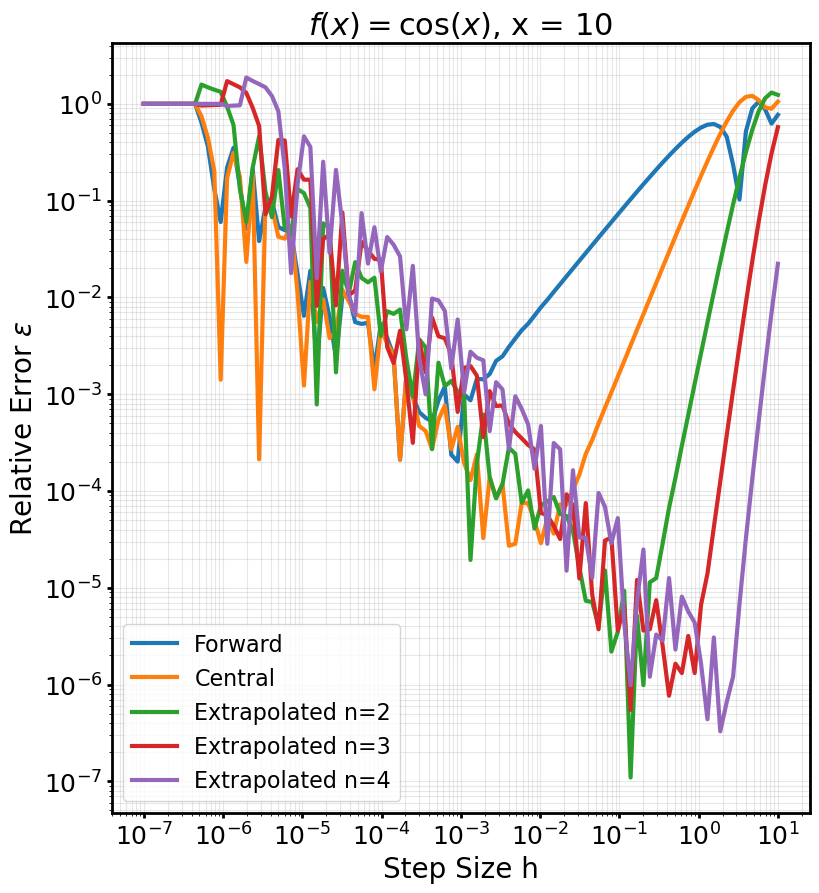


$f(x)=\cos(x)$, x=10
forward: h = 9.112e-04, min error = 2.012e-04, digits ~ 3.70
central: h = 4.037e-03, min error = 2.717e-05, digits ~ 4.57
extrapolated n=2: h = 1.385e-01, min error = 1.096e-07, digits ~ 6.96
extrapolated n=3: h = 1.385e-01, min error = 5.478e-07, digits ~ 6.26
extrapolated n=4: h = 1.874e+00, min error = 3.287e-07, digits ~ 6.48


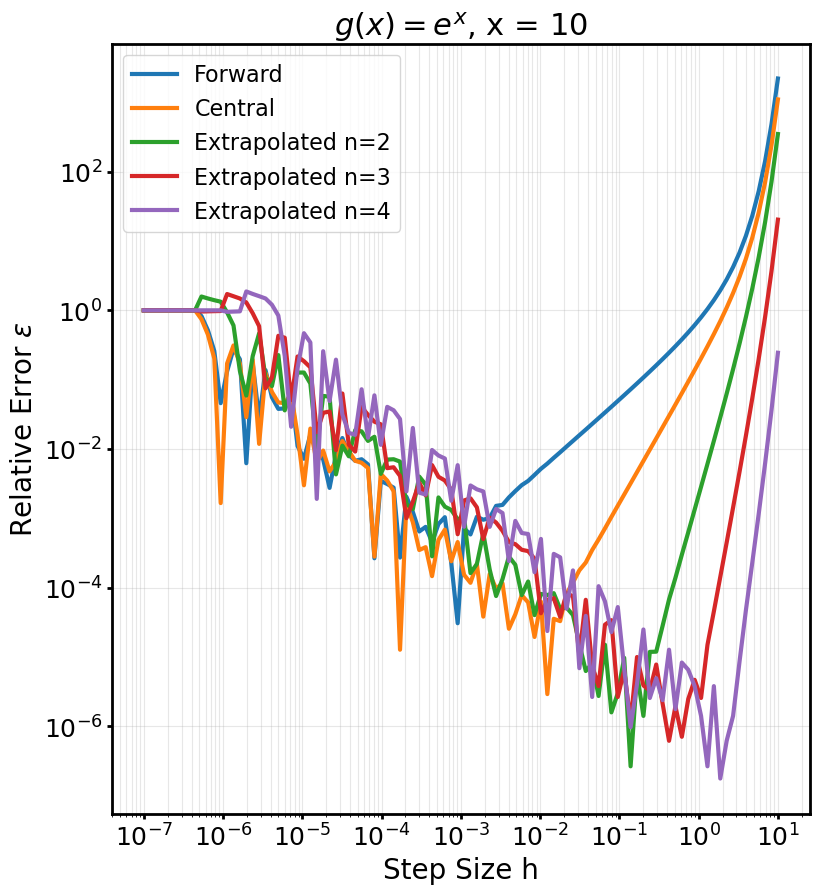


$g(x)=e^x$, x=10
forward: h = 9.112e-04, min error = 3.077e-05, digits ~ 4.51
central: h = 1.233e-02, min error = 2.926e-06, digits ~ 5.53
extrapolated n=2: h = 1.385e-01, min error = 2.660e-07, digits ~ 6.58
extrapolated n=3: h = 4.229e-01, min error = 6.207e-07, digits ~ 6.21
extrapolated n=4: h = 1.874e+00, min error = 1.773e-07, digits ~ 6.75


In [7]:
# plotting relative error vs step size (loglog)

for x in x_list:
    df_x = results_df[results_df["x"] == x]
    df_base = df_x[df_x["n"] == 2] # as to avoid repetitive plotting of forward and central

    for func, label in [("f", r"$f(x)=\cos(x)$"), ("g", r"$g(x)=e^x$")]:
        fig, ax = plt.subplots(figsize=(9,10))
        plt.loglog(df_base["h"], df_base[f"{func}_forward_error"], label="Forward")
        plt.loglog(df_base["h"], df_base[f"{func}_central_error"], label="Central")

        for n in [2,3,4]:
            df_n = df_x[df_x["n"] == n]
            plt.loglog(df_n["h"], df_n[f"{func}_extrapolated_error"], label=f"Extrapolated n={n}")

        # plt.axvline(x = 10**(-3.5), color='pink', linestyle='--', linewidth=2)
        plt.xlabel("Step Size h")
        plt.ylabel(r"Relative Error $\epsilon$")
        plt.title(f"{label}, x = {x}")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        fig.savefig(figures_dir / f"differentiation_results_{x}_{func}.png")
        plt.show()

        print(f"\n{label}, x={x}")

        for method in ["forward", "central"]:
            col = f"{func}_{method}_error"
            idx = df_base[col].idxmin()
            err = df_base.loc[idx, col]
            h_best = df_base.loc[idx, "h"]

            print(
                f"{method}: h = {h_best:.3e}, "
                f"min error = {err:.3e}, "
                f"digits ~ {-np.log10(err):.2f}"
            )

        for n in [2,3,4]:
            df_n = df_x[df_x["n"] == n]
            col = f"{func}_extrapolated_error"
            idx = df_n[col].idxmin()
            err = df_n.loc[idx, col]
            h_best = df_n.loc[idx, "h"]

            print(f"extrapolated n={n}: h = {h_best:.3e}, min error = {err:.3e}, digits ~ {-np.log10(err):.2f}")


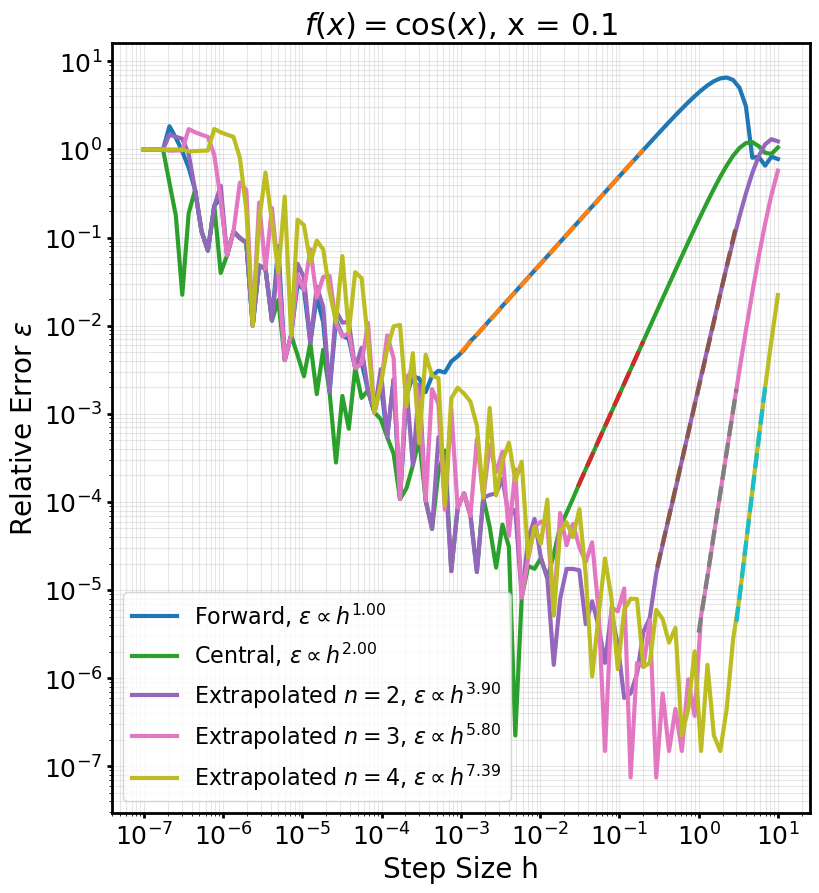

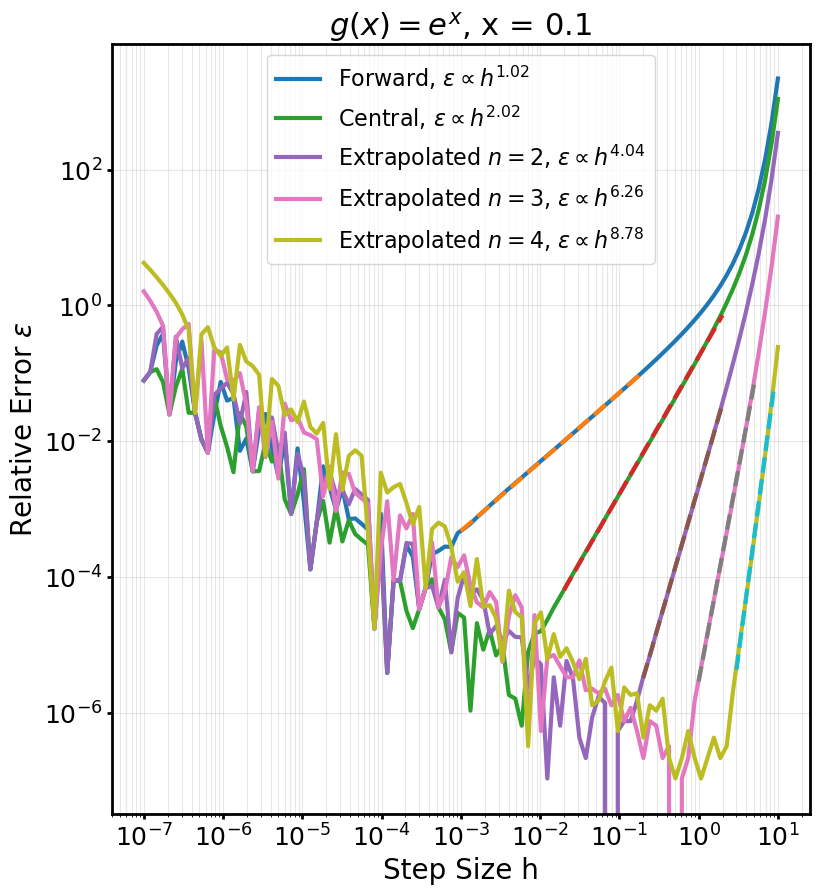

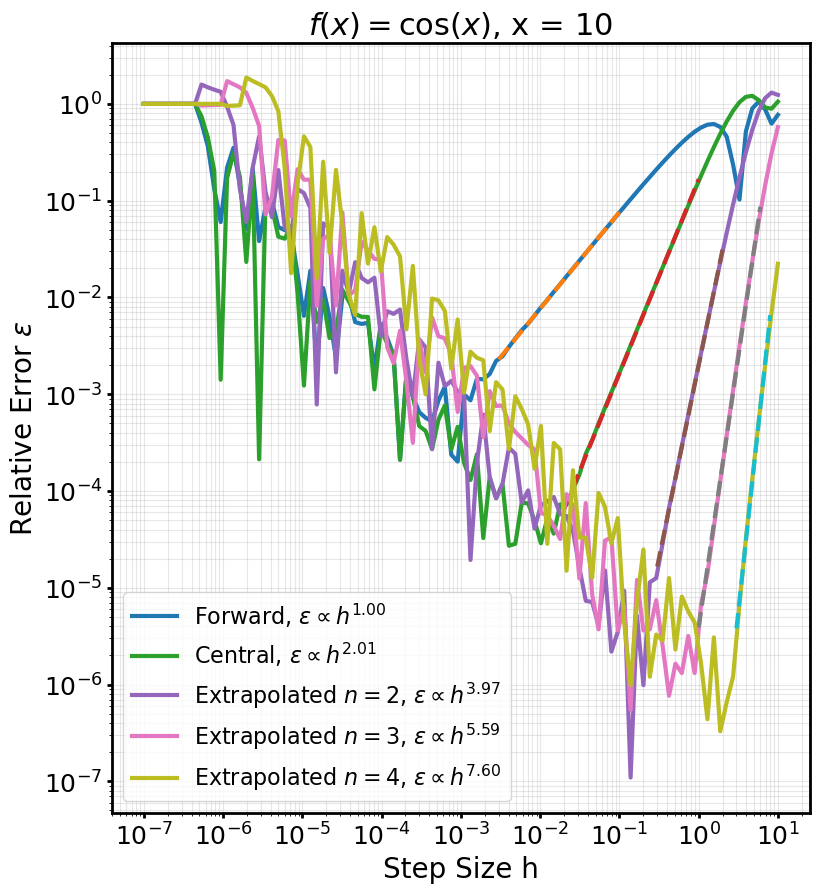

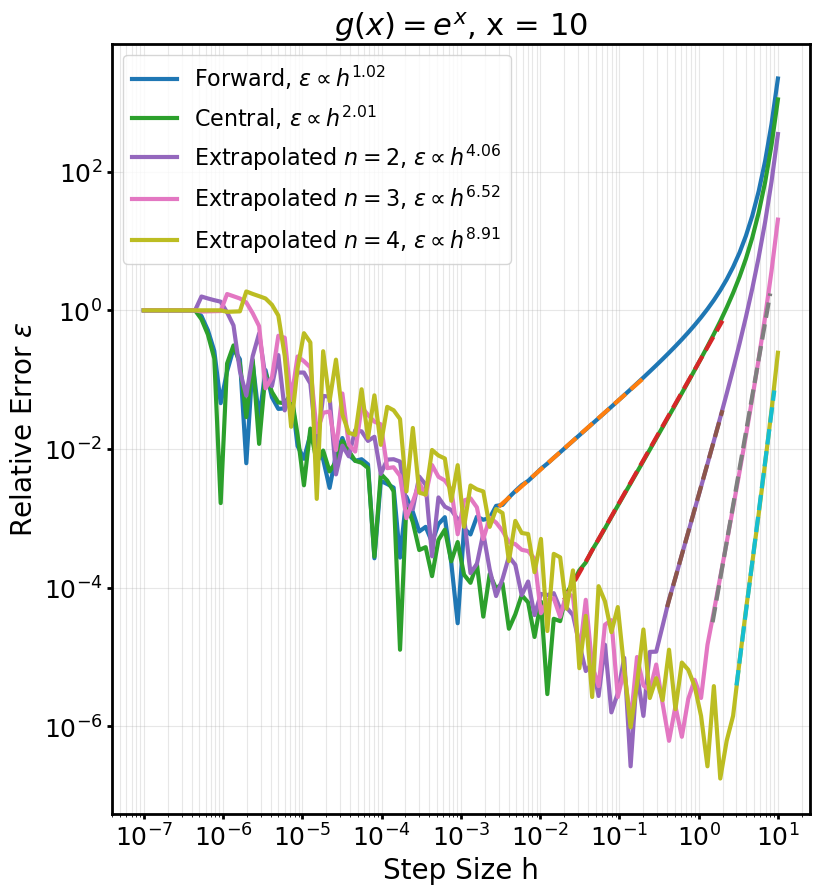

In [8]:
# let's check the scaling of error with h (fitting range in truncation error regime through visual inspection)

# f x = 10

forward_1 = [3e-3, 1e-1]
central_1 = [2e-2, 1]
richardson2_1 = [3e-1, 2]
richardson3_1 = [1,6]
richardson4_1 = [3,8]

# g x = 0.1

forward_2 = [1e-3, 2e-1]
central_2 = [2e-2, 2]
richardson2_2 = [2e-1,2]
richardson3_2 = [1, 5]
richardson4_2 = [3,9]

# f x = 0.1

forward_3 = [1e-3, 2e-1]
central_3 = [3e-2, 2e-1]
richardson2_3 = [3e-1, 3]
richardson3_3 = [1,3]
richardson4_3 = [3, 7]

# g x = 10

forward_4 = [3e-3, 2e-1]
central_4 = [2e-2, 2]
richardson2_4 = [4e-1, 2]
richardson3_4 = [1.5, 8]
richardson4_4 = [3, 9]

fit_ranges = {
    ("f", 10): {
        "forward": forward_1,
        "central": central_1,
        2: richardson2_1,
        3: richardson3_1,
        4: richardson4_1,
    },

    ("g", 0.1): {
        "forward": forward_2,
        "central": central_2,
        2: richardson2_2,
        3: richardson3_2,
        4: richardson4_2,
    },

    ("f", 0.1): {
        "forward": forward_3,
        "central": central_3,
        2: richardson2_3,
        3: richardson3_3,
        4: richardson4_3,
    },

    ("g", 10): {
        "forward": forward_4,
        "central": central_4,
        2: richardson2_4,
        3: richardson3_4,
        4: richardson4_4,
    },
}

def scaling_fit(df, error_col, bounds):
    fit = df[(df["h"] >= bounds[0]) & (df["h"] <= bounds[1]) & np.isfinite(df[error_col]) & (df[error_col] > 0)]
    log_h = np.log10(fit["h"].astype(float))
    log_error = np.log10(fit[error_col].astype(float))
    p, b = np.polyfit(log_h, log_error, 1)
    h_fit = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), 100)
    error_fit = 10**(p*np.log10(h_fit) + b)
    return p, h_fit, error_fit


for x in x_list:
    df_x = results_df[results_df["x"] == x]
    df_base = df_x[df_x["n"] == 2]
    for func, label in [("f", r"$f(x)=\cos(x)$"), ("g", r"$g(x)=e^x$")]:
        fig, ax = plt.subplots(figsize=(9,10))
        # forward
        bounds = fit_ranges[(func, x)]["forward"]
        p, h_fit, error_fit = scaling_fit(df_base, rf"{func}_forward_error",bounds)
        plt.loglog(df_base["h"], df_base[rf"{func}_forward_error"], label=rf"Forward, $\epsilon \propto h^{{{p:.2f}}}$")
        plt.loglog(h_fit, error_fit, "--")

        # central
        bounds = fit_ranges[(func, x)]["central"]
        p, h_fit, error_fit = scaling_fit(df_base, rf"{func}_central_error", bounds)
        plt.loglog(df_base["h"], df_base[rf"{func}_central_error"], label=rf"Central, $\epsilon \propto h^{{{p:.2f}}}$")
        plt.loglog(h_fit, error_fit, "--")

        # Richardson
        for n in [2, 3, 4]:
            df_n = df_x[df_x["n"] == n]
            bounds = fit_ranges[(func, x)][n]
            p, h_fit, error_fit = scaling_fit(df_n, rf"{func}_extrapolated_error", bounds)
            plt.loglog(df_n["h"], df_n[rf"{func}_extrapolated_error"], label=rf"Extrapolated $n={n}$, $\epsilon \propto h^{{{p:.2f}}}$")
            plt.loglog(h_fit, error_fit, "--")

        plt.xlabel("Step Size h")
        plt.ylabel(r"Relative Error $\epsilon$")
        plt.title(f"{label}, x = {x}")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        fig.savefig(figures_dir / f"differentiation_scaling_{x}_{func}.png")
        plt.show()

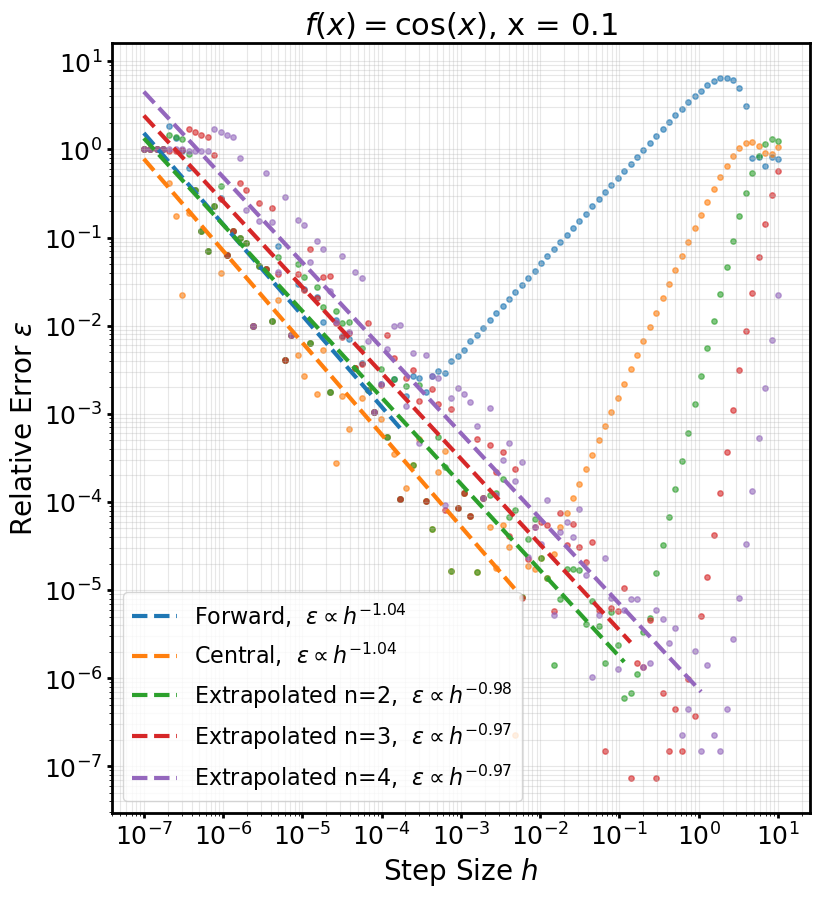

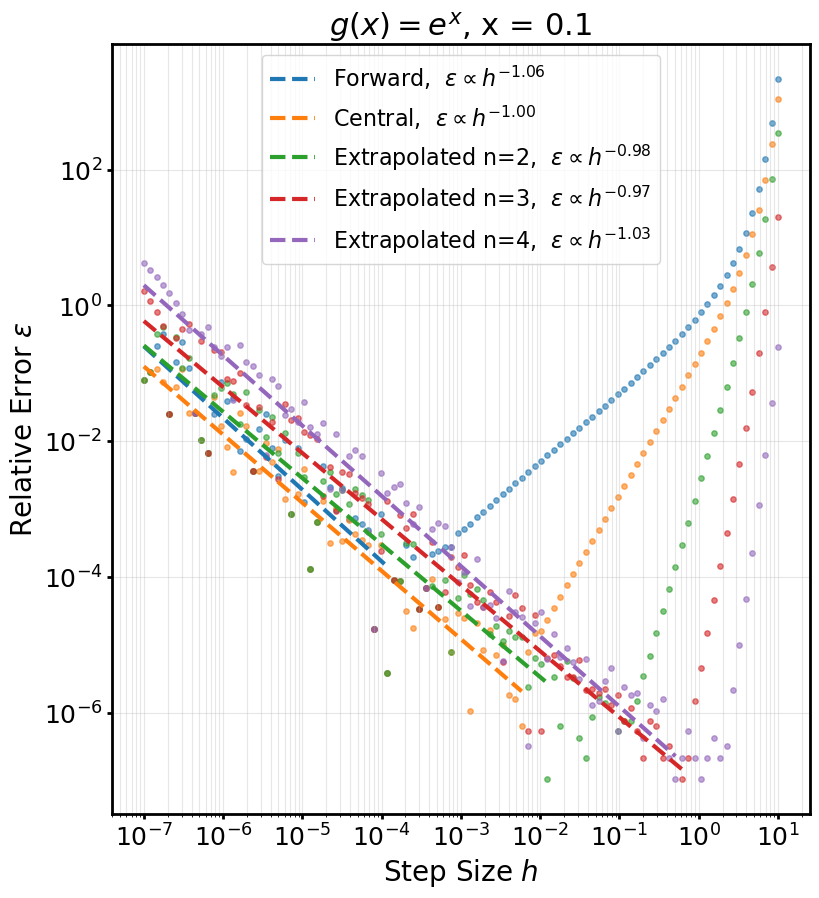

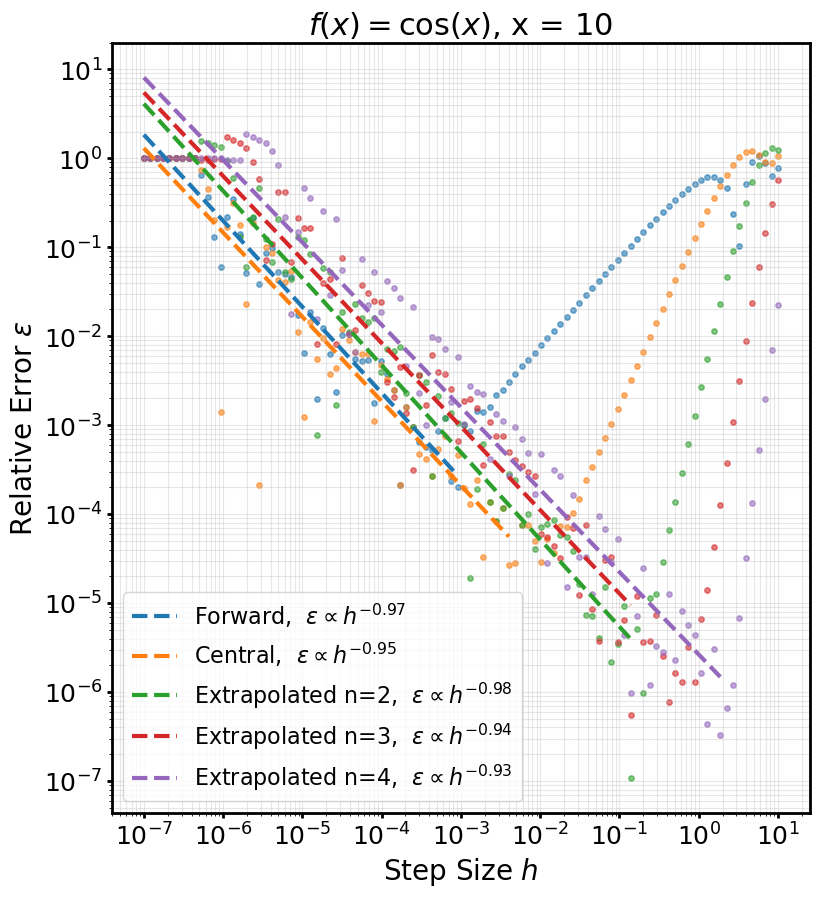

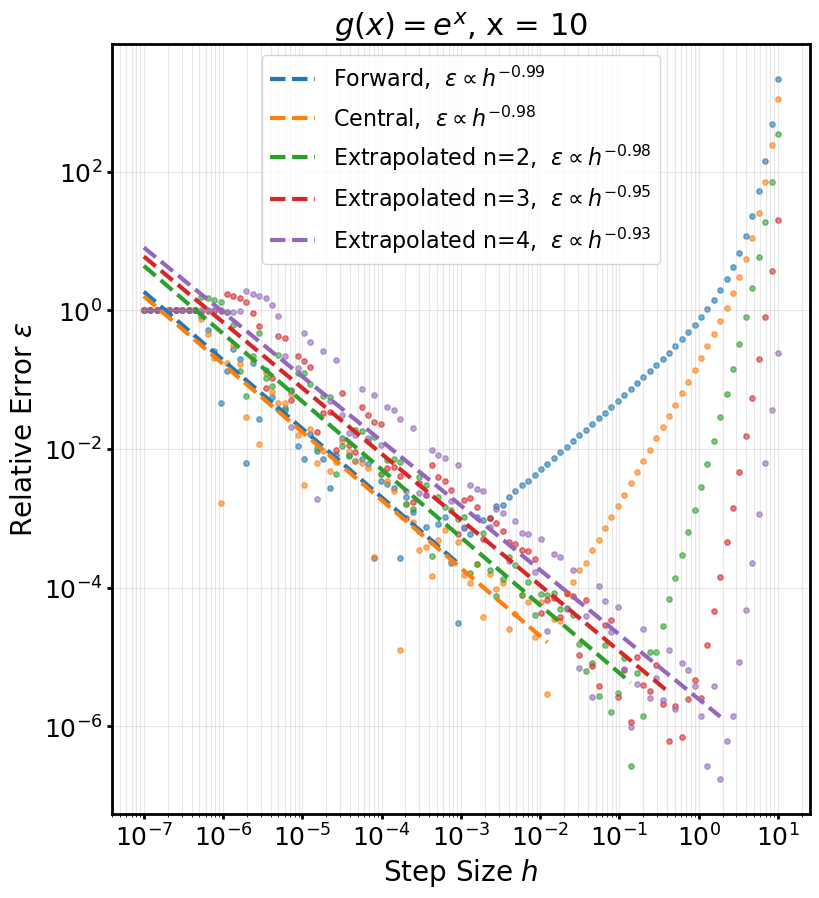

In [9]:
def negative_slope(df, error_col):
    h = df["h"].to_numpy(dtype=float)
    error = df[error_col].to_numpy(dtype=float)
    valid = (error > 0)
    h, error = h[valid], error[valid]
    h_opt = h[np.argmin(error)]
    mask = h <= h_opt
    p, b = np.polyfit(np.log10(h[mask]), np.log10(error[mask]), 1)
    h_fit = np.logspace(np.log10(h[mask].min()), np.log10(h[mask].max()), 100)
    error_fit = 10**b * h_fit**p
    return h, error, h_fit, error_fit, p

for x in x_list:
    df_x = results_df[results_df["x"] == x]
    df_base = df_x[df_x["n"] == 2]

    for func, label in [("f", r"$f(x)=\cos(x)$"), ("g", r"$g(x)=e^x$")]:
        methods = [(df_base, f"{func}_forward_error", "Forward"), (df_base, f"{func}_central_error", "Central")]

        for n in [2, 3, 4]:
            df_n = df_x[df_x["n"] == n]
            methods.append((df_n, f"{func}_extrapolated_error", f"Extrapolated n={n}"))

        fig, ax = plt.subplots(figsize=(9, 10))

        for i, (df_method, error_col, method) in enumerate(methods):
            h, error, h_fit, error_fit, p = negative_slope(df_method, error_col)
            ax.scatter(h, error, s=15, color=f"C{i}", alpha=0.6)
            ax.plot(h_fit, error_fit, "--", color=f"C{i}", label=rf"{method},  $\epsilon \propto h^{{{p:.2f}}}$")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Step Size $h$")
        ax.set_ylabel(r"Relative Error $\epsilon$")
        ax.set_title(f"{label}, x = {x}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

        fig.savefig(figures_dir / f"differentiation_roundoff_scaling_{x}_{func}.png", dpi=300, bbox_inches="tight")
        plt.show()

PROBLEM 2: Integration

In [10]:
# (a) integrate using midpoint rule, trapezoid rule, and simpson's rule for single precision 

def integrand(t):
    t = np.float32(t)
    return np.exp(-t)

upper_t = np.float32(1.0)
lower_t = np.float32(0.0)

def midpoint_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    j = np.arange(N, dtype=np.float32)
    x = a + (j + np.float32(0.5))*h
    integral = np.sum(f(x), dtype=np.float32)
    return integral * h

def trapezoid_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    j = np.arange(1, N, dtype=np.float32)
    x = a + j * h
    integral = np.float32(0.5) * f(a) + np.float32(0.5)* f(b) + np.sum(f(x), dtype=np.float32)
    return h * integral

def simpsons_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    x = a + np.arange(N+1, dtype=np.float32) * h
    f_x = f(x)
    integral = f_x[0] + f_x[-1] + np.float32(4) * np.sum(f_x[1:-1:2]) + np.float32(2) * np.sum(f_x[2:-1:2])
    return h/np.float32(3) * integral

definite_integral_exact = np.float32(1 - np.exp(-1))

N = np.unique(np.logspace(0, 30, num=100, base=2).astype(int))
N_simpsons = N[N % 2 == 0]  # we need even N for simpson's rule

midpoint_errors = []
trapezoid_errors = []
simpsons_errors = []

midpoint_results = []
trapezoid_results = []
simpsons_results = []

for n in N:
    midpoint_result = midpoint_rule(integrand, lower_t, upper_t, int(n))
    midpoint_results.append(midpoint_result)
    trapezoid_result = trapezoid_rule(integrand, lower_t, upper_t, int(n))
    trapezoid_results.append(trapezoid_result)
    
    midpoint_error = relative_error(midpoint_result, definite_integral_exact)
    trapezoid_error = relative_error(trapezoid_result, definite_integral_exact)
    midpoint_errors.append(relative_error(midpoint_result, definite_integral_exact))
    trapezoid_errors.append(relative_error(trapezoid_result, definite_integral_exact))

for n in N_simpsons:
    simpsons_result = simpsons_rule(integrand, lower_t, upper_t, int(n))
    simpsons_error = relative_error(simpsons_result, definite_integral_exact)
    simpsons_errors.append(simpsons_error)
    simpsons_results.append(simpsons_result)


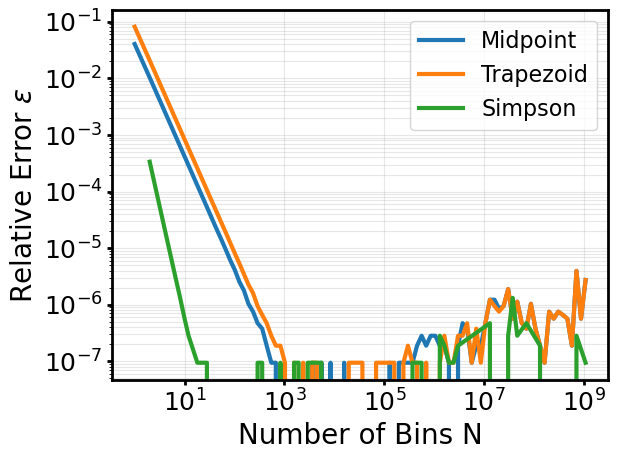

In [11]:
# (b) log-log plot of error as a function of number of bins N

plt.loglog(N, midpoint_errors, label="Midpoint")
plt.loglog(N, trapezoid_errors, label="Trapezoid")
plt.loglog(N_simpsons, simpsons_errors, label="Simpson")

plt.xlabel("Number of Bins N")
plt.ylabel(r"Relative Error $\epsilon$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

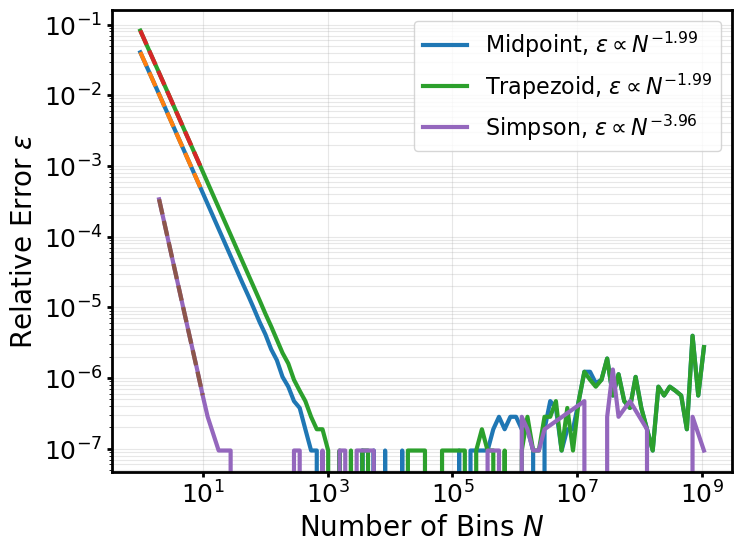

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for N_data, errors, name in [(N, midpoint_errors, "Midpoint"), (N, trapezoid_errors, "Trapezoid"), (N_simpsons, simpsons_errors, "Simpson")]:
    N_data = np.asarray(N_data)
    errors = np.asarray(errors)
    N_start = N_data[np.argmax(errors)]
    mask = (N_data >= N_start) & (N_data <= 10) & (errors > 0)
    slope, intercept = np.polyfit(np.log10(N_data[mask]), np.log10(errors[mask]), 1)
    fit = 10**intercept * N_data[mask]**slope
    ax.loglog(N_data, errors, label= rf"{name}, $\epsilon \propto N^{{{slope:.2f}}}$")
    ax.loglog(N_data[mask], fit, "--")

ax.set_xlabel("Number of Bins $N$")
ax.set_ylabel(r"Relative Error $\epsilon$")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.savefig(figures_dir / "integration_results.png", dpi=300, bbox_inches="tight")
plt.show()

PROBLEM 3: BAO Peak

          k       P_k
0  0.000100  651.3423
1  0.000102  665.7413
2  0.000105  680.4584
3  0.000107  695.5004
4  0.000110  710.8747
(701, 2)


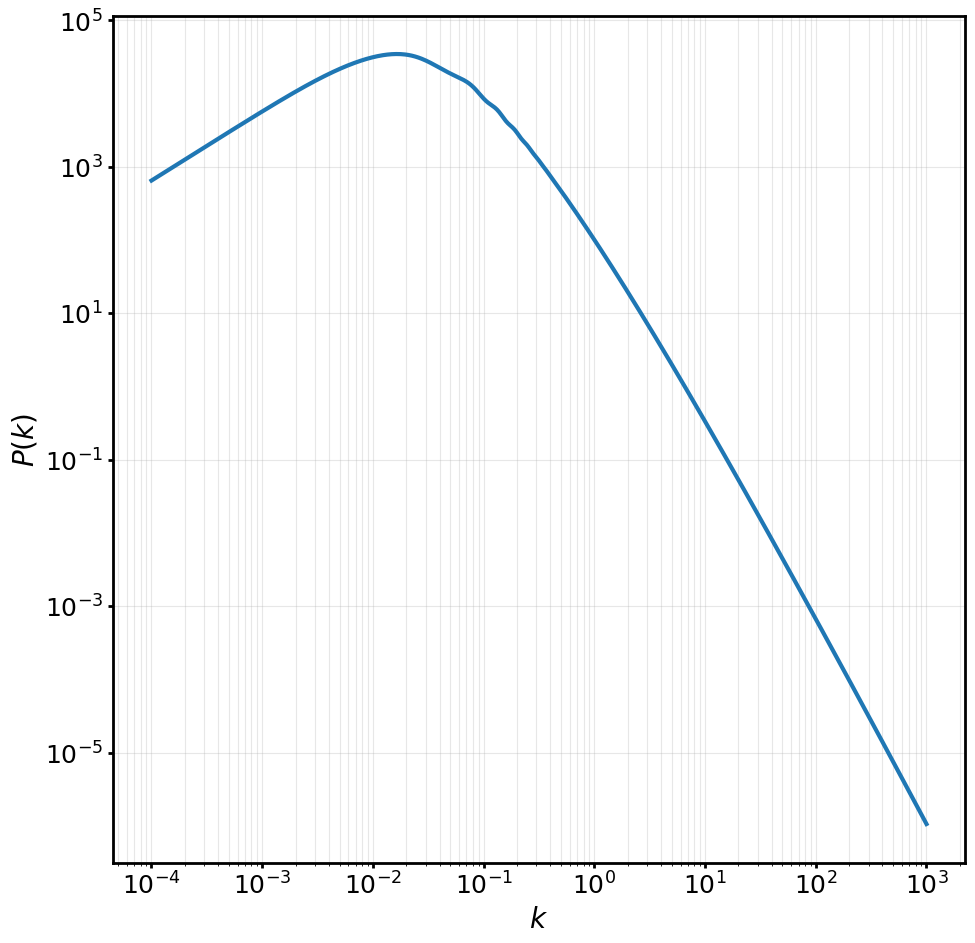

In [13]:
# plot the data file, first column is k, second column is P(k), ignore third column

power_spectrum = base_dir / "lcdm_z0.matter_pk"
df = pd.read_csv(power_spectrum, sep = r"\s+", header = None, usecols=[0, 1], names = ["k", "P_k"])
print(df.head())
print(df.shape)

fig, ax = plt.subplots(figsize=(11,11))
plt.loglog(df["k"], df["P_k"])
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.grid(True, which="both", alpha=0.3)
fig.savefig(figures_dir / "power_spectrum.png")
plt.show()



In [14]:
r = np.linspace(50, 120, 1000) # Mpc/h
k = df["k"].to_numpy(dtype=np.float32)
P_k = df["P_k"].to_numpy(dtype=np.float32)

In [15]:
print(k.min(), k.max())

1e-04 1000.0


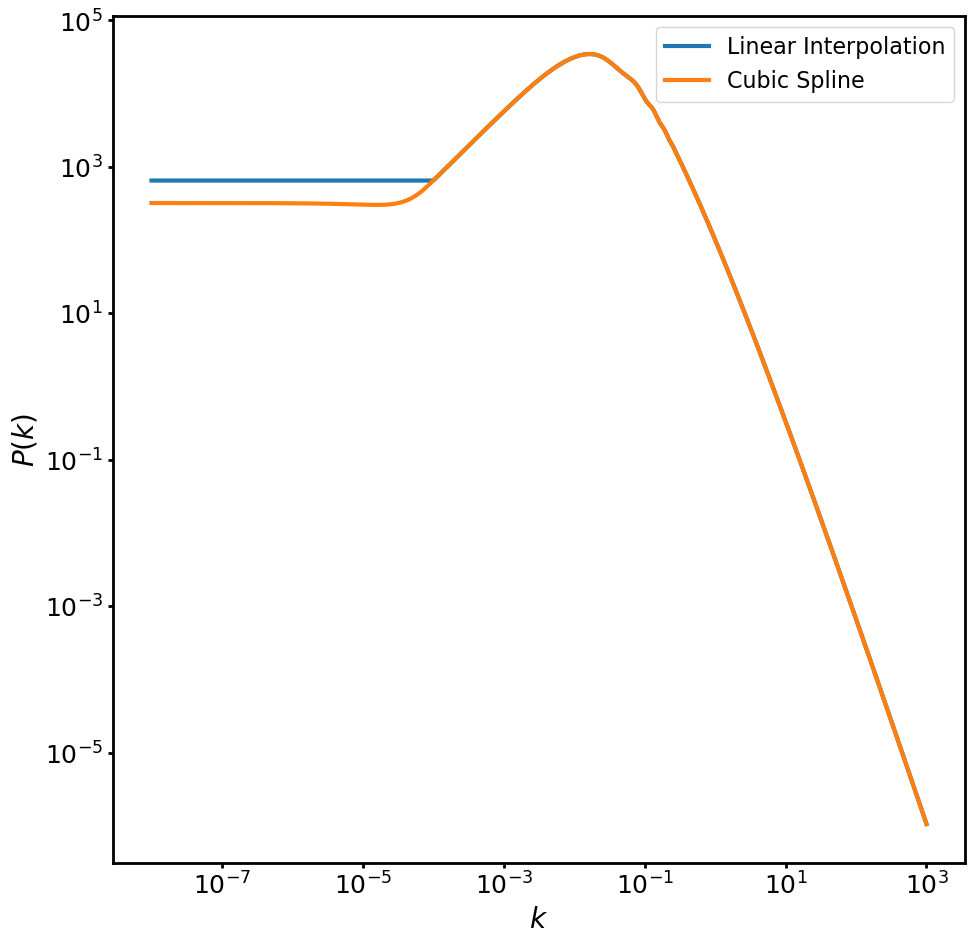

In [16]:
P_k_spline_function = CubicSpline(k, P_k, bc_type='natural')

def linear_interp(x, k, P_k):
    x = np.clip(x, k[0], k[-1])
    idx1 = np.searchsorted(k, x)
    idx1 = np.where(idx1 == 0, 1, idx1)
    idx1 = np.where(idx1 == len(k), len(k)-1, idx1)
    idx0 = idx1 - 1
    x0, x1 = k[idx0], k[idx1]
    y0, y1 = P_k[idx0], P_k[idx1]
    P_k_interp = y0 + (x - x0) * (y1 - y0) / (x1 - x0)
    return P_k_interp

def P_k_spline(k_i):
    return P_k_spline_function(k_i)

def P_k_linear(k_i):
    return linear_interp(k_i, k, P_k)

k_new = np.logspace(-8, 3, 1000, dtype=np.float32)

P_k_cubic = P_k_spline(k_new)
P_k_linear_values = P_k_linear(k_new)
fig, ax = plt.subplots(figsize=(11, 11))
plt.loglog(k_new, P_k_linear_values, label='Linear Interpolation')
plt.loglog(k_new, P_k_cubic, label='Cubic Spline')
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.legend()
fig.savefig(figures_dir / "interpolation.png")
plt.show()

In [17]:
def int_linear(r):
    factor = np.float64(1) / np.float64(2 * np.pi**2)
    def integrand(k_i):
        return k_i**2 * P_k_linear(k_i) * (np.sin(k_i * r) / (k_i * r))
    integral = factor * simpsons_rule(integrand, k_new[0], k_new[-1], 100000)
    return integral

def int_spline(r):
    factor = np.float64(1) / np.float64(2 * np.pi**2)
    def integrand(k_i):
        return k_i**2 * P_k_spline(k_i) * (np.sin(k_i * r) / (k_i * r))
    integral = factor * simpsons_rule(integrand, k_new[0], k_new[-1], 100000)
    return integral

In [18]:
xi_spline = np.array([int_spline(r_i) for r_i in r])

In [19]:
r_squared_xi = r**2 * xi_spline
peak_indices = np.where((r_squared_xi[1:-1] > r_squared_xi[:-2]) & (r_squared_xi[1:-1] > r_squared_xi[2:]))[0] + 1
peak_index = peak_indices[np.argmax(r_squared_xi[peak_indices])]
r_peak = r[peak_index]
peak_value = r_squared_xi[peak_index]
print(r_peak, peak_value)

105.63563563563564 18.028860102242596


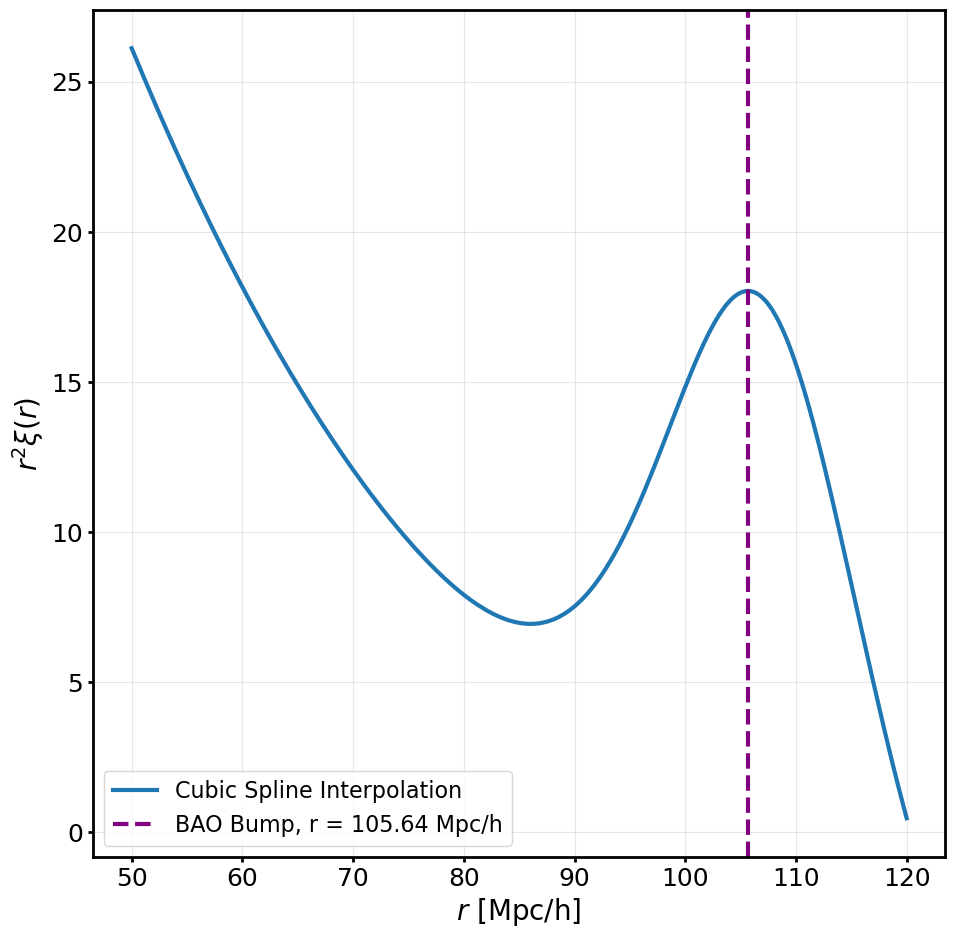

In [20]:
fig, ax = plt.subplots(figsize=(11,11))
plt.plot(r, r**2 * xi_spline, label="Cubic Spline Interpolation")
plt.axvline(x=r_peak, color='purple', linestyle='--', label = f"BAO Bump, r = {r_peak:.2f} Mpc/h")
plt.xlabel(r"$r$ [Mpc/h]")
plt.ylabel(r"$r^2 \xi(r)$")
plt.grid(alpha=0.3)
plt.legend()
fig.savefig(figures_dir / "correlation_function_cubic.png")
plt.show()



In [21]:
# extra credit: linear vs cubic spline interpolation fractional difference
xi_linear = np.array([int_linear(r_i) for r_i in r])
fractional_error = np.abs((xi_linear - xi_spline) / xi_spline)

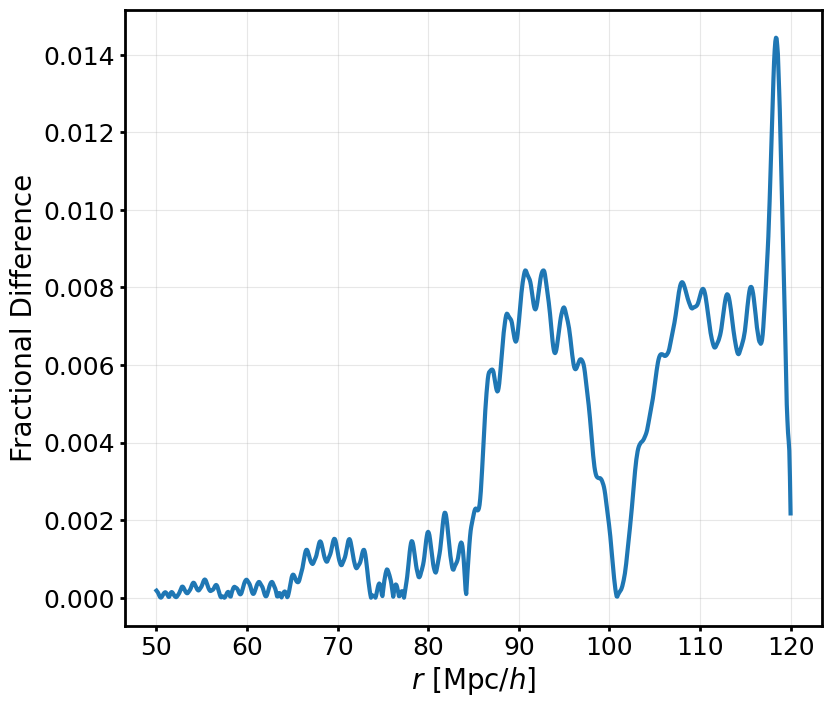

In [22]:
fig, ax = plt.subplots(figsize=(9,8))
plt.plot(r, fractional_error)
plt.xlabel(r"$r$ [Mpc/$h$]")
plt.ylabel(r"Fractional Difference")
plt.grid(alpha=0.3)
fig.savefig(figures_dir / "correlation_function_fractional_error.png", bbox_inches='tight')
plt.show()

In [23]:
r_squared_xi_linear = r**2 * xi_linear
peak_indices = np.where((r_squared_xi_linear[1:-1] > r_squared_xi_linear[:-2]) & (r_squared_xi_linear[1:-1] > r_squared_xi_linear[2:]))[0] + 1
peak_index = peak_indices[np.argmax(r_squared_xi_linear[peak_indices])]
r_peak = r[peak_index]
peak_value = r_squared_xi_linear[peak_index]
print(r_peak, peak_value)

105.63563563563564 17.915824521432867


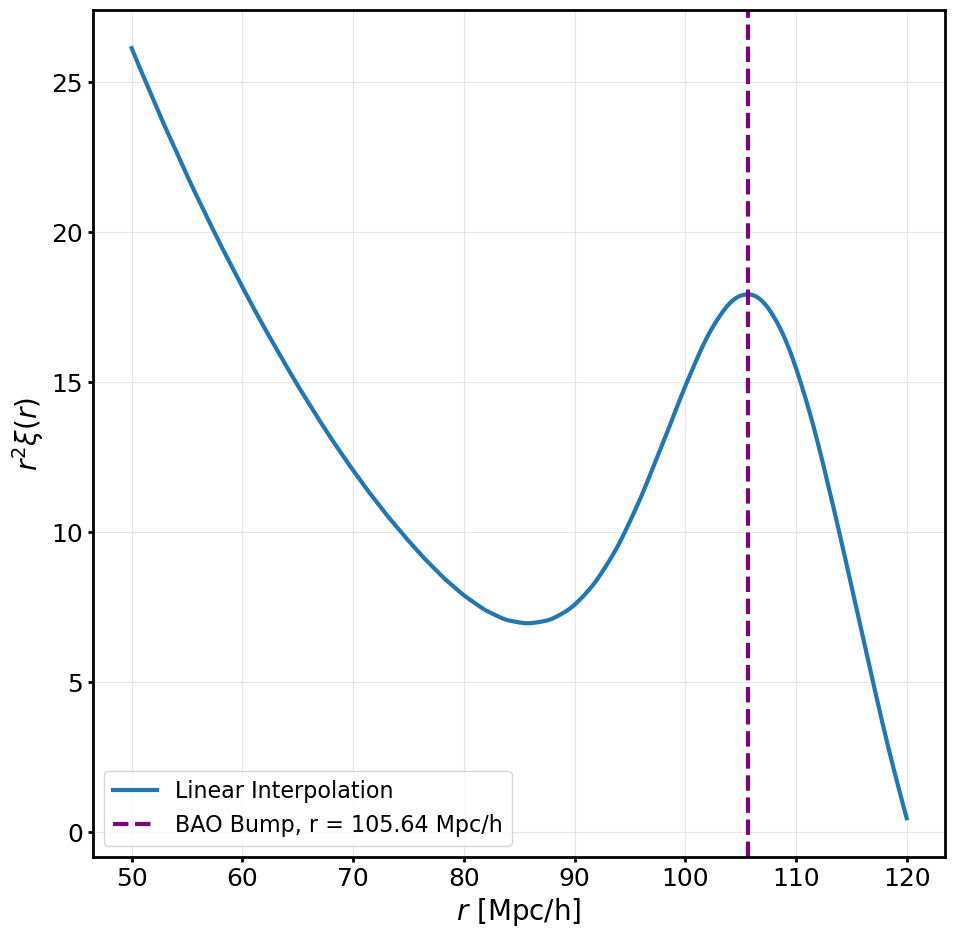

In [24]:
fig, ax = plt.subplots(figsize=(11, 11))
plt.plot(r, r**2 * xi_linear, label="Linear Interpolation")
plt.axvline(x=r_peak, color='purple', linestyle='--', label = f"BAO Bump, r = {r_peak:.2f} Mpc/h")
plt.xlabel(r"$r$ [Mpc/h]")
plt.ylabel(r"$r^2 \xi(r)$")
plt.grid(alpha=0.3)
plt.legend()
fig.savefig(figures_dir / "correlation_function_linear.png")
plt.show()